In [1]:
import pandas as pd
import numpy as np
import os 
from pathlib import Path

%matplotlib inline

import matplotlib.pyplot as plt

import seaborn as sn

In [2]:
list(Path('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/').glob("*"))

[PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/.ipynb_checkpoints'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_bg_noise'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_n_talkers_snr'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_snr_ranges'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_cue_jsin_pilot_no_pretrain_bs_64_lr_1e-4'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_cue_jsin_pilot_no_pretrain_norm_at_input_bs_64_lr_1e-4'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_cue_jsin_pilot_no_pretrain_norm_at_input_pos_slope_bs_64_lr_1e-4'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_cue_jsin_pilot_no_pretrain_pos_slope_bs_64_lr_1e-4')]

In [3]:
# Get csvs of results for each model 

def get_df_from_dir(model_paths, talker=False):
    csv_str = 'metrics.csv'
    #models = [attn_models[0], ctrl_models[0]]
    bad_files = []
    dfs = []
    for model in model_paths:
        # get test csvs
        results_csvs = model.rglob("*.csv")

        for csv in results_csvs:
    #         print(csv)
            try:
                df = pd.read_csv(csv)
                #print(model)

                df['version'] = csv.as_posix().split(model.stem)[-1].split('/')[1].split('_')[-1]
                test_parts = str(model).split("/")[-1].split("_")
                #print(test_parts)
                if talker:
                    df['model'] = test_parts[2]
                    df['snr_condition'] = test_parts[3]
                    df['n_talkers'] = test_parts[0]
                else:
                    df['model'] = test_parts[0]
            #       print(test_parts)
                    df['snr_condition'] = test_parts[1]

                if len(df.filter(regex='acc_step').columns) != 0:
                    df["ACC/test_fg_acc"] = df["ACC/test_fg_acc_step"]
                    df["ACC/test_bg_acc"] = df["ACC/test_bg_acc_step"]

                dfs.append(df)
            except Exception as e:
                print(e)
                bad_files.append((csv.as_posix(), e))

    #         if 'Test' in path.as_posix()
    results = pd.concat(dfs, axis=0, ignore_index=True)

    # results.drop('ACC/test_fg_acc_epoch', axis=1, inplace=True)
    # results.drop('ACC/test_bg_acc_epoch', axis=1, inplace=True)
    # results.drop('epoch', axis=1, inplace=True)
    if talker:
        version_maxes = results.groupby(['model', 'snr_condition', 'n_talkers']).version.transform(max)
    else:
        version_maxes = results.groupby(['model', 'snr_condition']).version.transform(max)
    results = results[results.version == version_maxes]
    return results, bad_files 

In [4]:
bg_models = list(Path('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_bg_noise').glob("*"))
snr_models = list(Path('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_snr_ranges').glob("*"))
# talker_models = list(Path('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_n_talkers_snr').glob("*"))

audioset_bg = list(Path('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_bg_noise/').glob("*"))
audioset_snr = list(Path('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_snr_ranges/').glob("*"))



In [53]:
talker_results

,ACC/test_fg_acc,step,version,model,snr_condition,n_talkers
0,1.0,0,0,AttnCNNConstrained,-10dB,1
1,1.0,1,0,AttnCNNConstrained,-10dB,1
2,1.0,2,0,AttnCNNConstrained,-10dB,1
3,1.0,3,0,AttnCNNConstrained,-10dB,1
4,1.0,4,0,AttnCNNConstrained,-10dB,1
...,...,...,...,...,...,...
2209184,0.0,16807,0,AttnTrackingControl,clean,4
2209185,1.0,16808,0,AttnTrackingControl,clean,4
2209186,0.0,16809,0,AttnTrackingControl,clean,4
2209187,0.0,16810,0,AttnTrackingControl,clean,4


In [5]:
bg_results, _ = get_df_from_dir(bg_models)
snr_results, _ = get_df_from_dir(snr_models)
# talker_results, _ = get_df_from_dir(talker_models, talker=True)

aud_bg,  _ = get_df_from_dir(audioset_bg)
aud_snr,  _ = get_df_from_dir(audioset_snr)


No columns to parse from file
No columns to parse from file
No columns to parse from file


In [20]:
snr_results['test_confusion'] = snr_results['fg_confusion']

In [21]:
aud_snr.model.unique(), snr_results.model.unique()

(array(['AudiosetBackground'], dtype=object),
 array(['AttnCNNConstrained', 'AttnCNNPosSlope', 'AttnCNN',
        'AttnTrackingControl'], dtype=object))

In [22]:
# !head -n 5 ../attn_cue_models/attn_check_snr_ranges/AttnTrackingControl_clean/version_1/metrics.csv

In [23]:
all_bg_results = pd.concat([bg_results, aud_bg], axis=0, ignore_index=True)
all_snr_results = pd.concat([snr_results, aud_snr], axis=0, ignore_index=True)

In [ ]:
# filtered_results['attended_accuracy'] = (filtered_results['ACC/test_fg_acc_step'] + filtered_results['ACC/test_bg_acc_step'])/2
# filtered_results

## Compare models trained with single talker distractors to models trained with audioset distractors 



In [37]:
## Just want the constrained talker & audioset models

snr_data_for_plot = all_snr_results[all_snr_results.model.str.contains('AttnCNNConstrained|AudiosetBackground')]
bg_data_for_plot = all_bg_results[all_bg_results.model.str.contains('AttnCNNConstrained|AudiosetBackground')]


# Change model names for plotting
snr_data_for_plot['model'].replace('AttnCNNConstrained','single talker',inplace=True)
snr_data_for_plot['model'].replace('AudiosetBackground','audioset - no speech or music',inplace=True)

bg_data_for_plot['model'].replace('AttnCNNConstrained','single talker',inplace=True)
bg_data_for_plot['model'].replace('AudiosetBackground','audioset - no speech or music',inplace=True)


/tmp/ipykernel_99390/2519791179.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  snr_data_for_plot['model'].replace('AttnCNNConstrained','single talker',inplace=True)
/tmp/ipykernel_99390/2519791179.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  snr_data_for_plot['model'].replace('AudiosetBackground','audioset - no speech or music',inplace=True)
/tmp/ipykernel_99390/2519791179.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [38]:
# Match names 


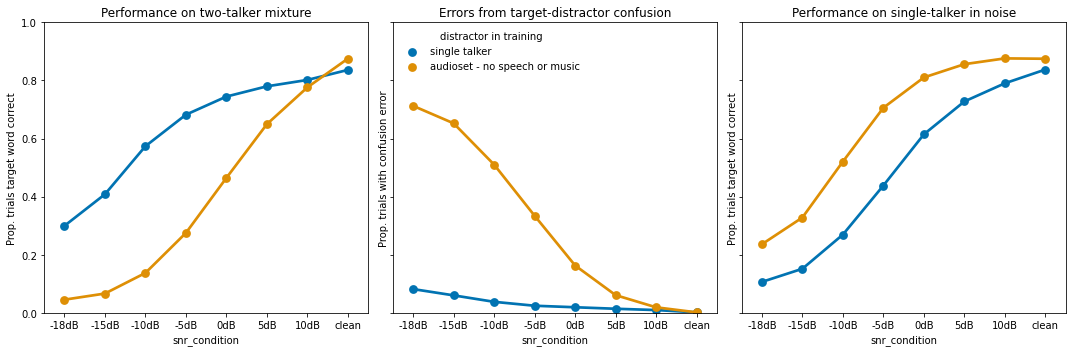

In [45]:
fig, axs = plt.subplots(1,3, sharey=True, figsize=(15,5))
axs = axs.ravel()

snr_order = ['-18dB', '-15dB', '-10dB', '-5dB', '0dB', '5dB', '10dB', 'clean']

g = sn.pointplot(
    data=snr_data_for_plot, x='snr_condition',y='ACC/test_fg_acc',
    hue='model', #hue_order=hue_order,
    ci=95, seed=1, ax=axs[0],
    palette='colorblind', order=snr_order
)


g1 = sn.pointplot(
    data=snr_data_for_plot,
    x='snr_condition',y='test_confusion',
    hue='model',# hue_order=['cued model'],
    ci=95, seed=1, ax=axs[1], 
    palette='colorblind', order=snr_order
)


g2 = sn.pointplot(
    data=bg_data_for_plot, x='snr_condition', y='ACC/test_fg_acc',
    hue='model', #hue_order=hue_order,
    ci=95, seed=1, ax=axs[2],
    palette='colorblind', order=snr_order
)



axs[0].set_title("Performance on two-talker mixture")
axs[1].set_title("Errors from target-distractor confusion")
axs[2].set_title("Performance on single-talker in noise")


axs[0].set_ylabel("Prop. trials target word correct")
axs[1].set_ylabel("Prop. trials with confusion error")
axs[2].set_ylabel("Prop. trials target word correct")

axs[0].set_ylim((0,1))
axs[1].set_ylim((0,1))
axs[2].set_ylim((0,1))

# axs[0].legend(title='distractor in training', loc='lower right', frameon=False)
axs[0].get_legend().remove()
axs[1].legend(title='distractor in training', loc='upper left', frameon=False)
# axs[2].legend(title='distractor in training', frameon=False)
axs[2].get_legend().remove()


plt.tight_layout()



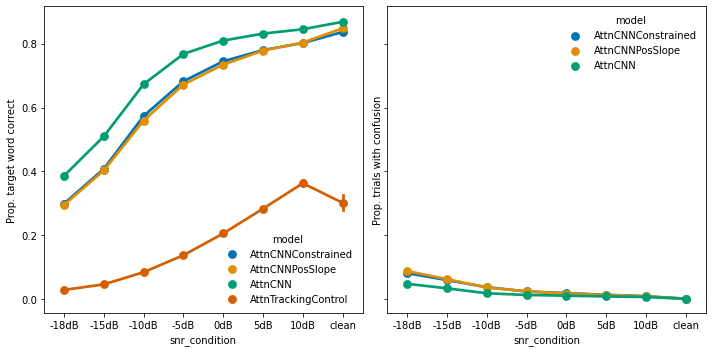

In [131]:
fig, axs = plt.subplots(1,2, sharey=True, figsize=(10,5))
axs = axs.ravel()

g = sn.pointplot(
    data=snr_results, x='snr_condition',y='ACC/test_fg_acc',
    hue='model', #hue_order=['unconstrained slope', 'constrained slope', "control"],
    ci=95, seed=1, ax=axs[0],
    palette='colorblind', order=['-18dB', '-15dB', '-10dB', '-5dB', '0dB', '5dB', '10dB', 'clean']
)


g1 = sn.pointplot(
    data=snr_results[snr_results.model != 'AttnTrackingControl'], x='snr_condition',y='fg_confusion',
    hue='model', #  hue_order=['unconstrained slope', 'constrained slope'],
    ci=95, seed=1, ax=axs[1],
    palette='colorblind', order=['-18dB', '-15dB', '-10dB', '-5dB', '0dB', '5dB', '10dB', 'clean']
)

g.set_ylabel("Prop. target word correct")

axs[0].legend(title='model', loc='lower right', frameon=False)
axs[1].legend(title='model', frameon=False)

g1.set_ylabel("Prop. trials with confusion")

plt.tight_layout()



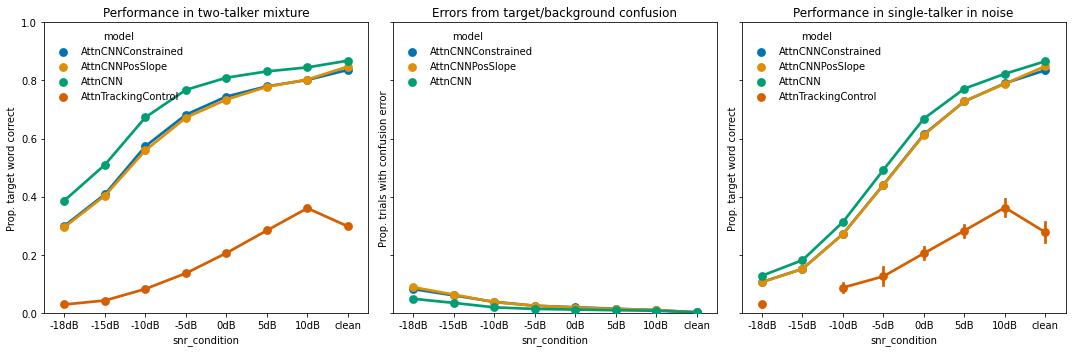

In [53]:
fig, axs = plt.subplots(1,3, sharey=True, figsize=(15,5))
axs = axs.ravel()

# hue_order = ['cued model', "control model"]
snr_order = ['-18dB', '-15dB', '-10dB', '-5dB', '0dB', '5dB', '10dB', 'clean']

g = sn.pointplot(
    data=snr_results, x='snr_condition',y='ACC/test_fg_acc',
    hue='model', #hue_order=hue_order,
    ci=95, seed=1, ax=axs[0],
    palette='colorblind', order=snr_order
)


g1 = sn.pointplot(
    data=snr_results[snr_results.model != 'AttnTrackingControl'],
    x='snr_condition',y='fg_confusion',
    hue='model',# hue_order=['cued model'],
    ci=95, seed=1, ax=axs[1],
    palette='colorblind', order=snr_order
)


g2 = sn.pointplot(
    data=bg_results, x='snr_condition', y='ACC/test_fg_acc',
    hue='model', #hue_order=hue_order,
    ci=95, seed=1, ax=axs[2],
    palette='colorblind', order=snr_order
)



axs[0].set_title("Performance in two-talker mixture")
axs[1].set_title("Errors from target/background confusion")
axs[2].set_title("Performance in single-talker in noise")


axs[0].set_ylabel("Prop. target word correct")
axs[1].set_ylabel("Prop. trials with confusion error")
axs[2].set_ylabel("Prop. target word correct")

axs[0].set_ylim((0,1))
axs[1].set_ylim((0,1))
axs[2].set_ylim((0,1))

axs[0].legend(title='model', loc='lower right', frameon=False)
axs[1].legend(title='model', loc='upper left', frameon=False)
axs[2].legend(title='model', frameon=False)


plt.tight_layout()



## Make summary plots with wanted models 

In [56]:
talker_plot = talker_results[talker_results.model.str.contains('AttnCNNPosSlope|AttnTrackingControl')]

snr_plot = snr_results[snr_results.model.str.contains('AttnCNNPosSlope|AttnTrackingControl')]
bg_plot = bg_results[bg_results.model.str.contains('AttnCNNPosSlope|AttnTrackingControl')]

In [57]:

bg_plot['model'].replace('AttnCNNPosSlope','cued model',inplace=True)
bg_plot['model'].replace('AttnTrackingControl','control model',inplace=True)

snr_plot['model'].replace('AttnCNNPosSlope','cued model',inplace=True)
snr_plot['model'].replace('AttnTrackingControl','control model',inplace=True)

talker_plot['model'].replace('AttnCNNPosSlope','cued model',inplace=True)
talker_plot['model'].replace('AttnTrackingControl','control model',inplace=True)


<ipython-input-57-aba0597f7b16>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bg_plot['model'].replace('AttnCNNPosSlope','cued model',inplace=True)
<ipython-input-57-aba0597f7b16>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bg_plot['model'].replace('AttnTrackingControl','control model',inplace=True)
<ipython-input-57-aba0597f7b16>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  snr_plot['model'].replace('AttnCNNPosSlope','cued

In [58]:
talker_plot.model.unique()

array(['cued model', 'control model'], dtype=object)

#### Set colors for multi-talker plots

In [109]:
# combine strings for legend
talker_hue_tags = talker_plot['model'] + ' ' + talker_plot['n_talkers'] + '-distractor'
# get order of model-talker conditions 
talker_hue_order = np.sort(talker_hue_tags.unique())
# put in order for diverging color map: cue 1-4, control 4-1
talker_hue_order = np.hstack([talker_hue_order[4:], talker_hue_order[:4][::-1]])
# set color map and get color dict
talker_cmap = sn.color_palette("coolwarm", len(talker_hue_order), as_cmap=False)
talker_palette = {cond:talker_cmap[ix] for ix, cond in enumerate(talker_hue_order)}
# get wanted order: cue 1-4 control 1-4
talker_hue_order = np.hstack([talker_hue_order[:4], talker_hue_order[4:][::-1]])



In [110]:
talker_hue_order , talker_palette

(array(['cued model 1-distractor', 'cued model 2-distractor',
        'cued model 3-distractor', 'cued model 4-distractor',
        'control model 1-distractor', 'control model 2-distractor',
        'control model 3-distractor', 'control model 4-distractor'],
       dtype=object),
 {'cued model 1-distractor': (0.3634607953411765,
   0.4847836818509804,
   0.9010188868941177),
  'cued model 2-distractor': (0.5108243242509803,
   0.6493966148235294,
   0.9850787763764707),
  'cued model 3-distractor': (0.6672529243333334,
   0.7791764569999999,
   0.992959213),
  'cued model 4-distractor': (0.8049647588235295,
   0.8516661605568627,
   0.9261650744313725),
  'control model 4-distractor': (0.9193759889058823,
   0.8312727235294118,
   0.7828736304470588),
  'control model 3-distractor': (0.968203399, 0.7208441, 0.6122929913333334),
  'control model 2-distractor': (0.9440545734235294,
   0.5531534787490197,
   0.4355484903137255),
  'control model 1-distractor': (0.8523781350078431,
   0.

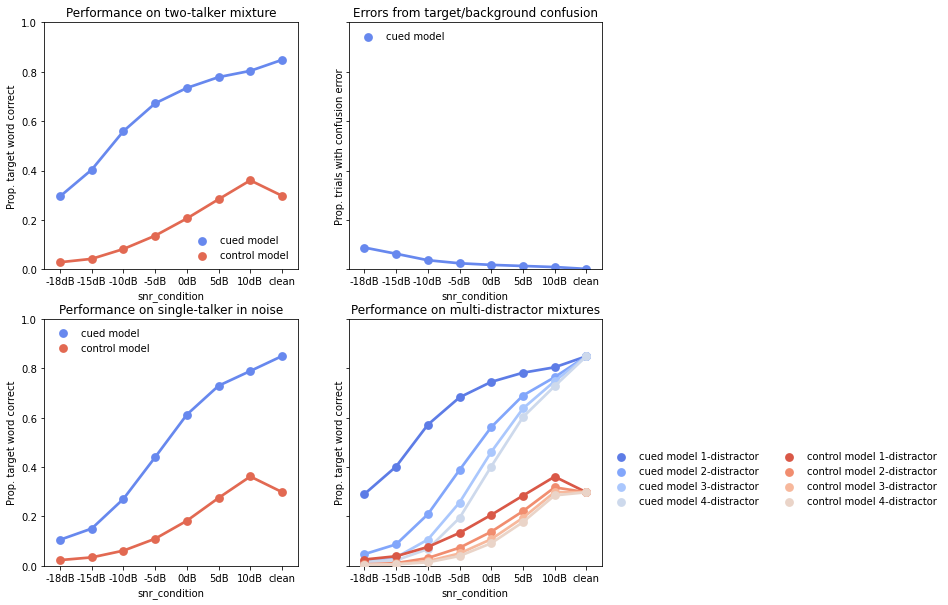

In [111]:
snr_order = ['-18dB', '-15dB', '-10dB', '-5dB', '0dB', '5dB', '10dB', 'clean']

# set single-model plots to match palette 
model_paletts = {'cued model': sn.color_palette("coolwarm", as_cmap=False)[0],
                 'control model': sn.color_palette("coolwarm", as_cmap=False)[-1]
}

fig, axs = plt.subplots(2,2, sharey=True, figsize=(10,10))
axs = axs.ravel()

# hue_order = ['cued model', "control model"]
snr_order = ['-18dB', '-15dB', '-10dB', '-5dB', '0dB', '5dB', '10dB', 'clean']

g = sn.pointplot(
    data=snr_plot, x='snr_condition',y='ACC/test_fg_acc',
    hue='model', #hue_order=hue_order,
    ci=95, seed=1, ax=axs[0],
    palette=model_paletts, order=snr_order
)


g1 = sn.pointplot(
    data=snr_plot[snr_plot.model != 'control model'],
    x='snr_condition',y='fg_confusion',
    hue='model',# hue_order=['cued model'],
    ci=95, seed=1, ax=axs[1],
    palette=model_paletts, order=snr_order
)


g2 = sn.pointplot(
    data=bg_plot, x='snr_condition', y='ACC/test_fg_acc',
    hue='model', #hue_order=hue_order,
    ci=95, seed=1, ax=axs[2],
    palette=model_paletts, order=snr_order
)

g3 = sn.pointplot(
    data=talker_plot,
    x='snr_condition', y='ACC/test_fg_acc',
#     col='n_talkers', col_wrap=2,
    hue=talker_hue_tags,
    hue_order=talker_hue_order,
#     ci=95, seed=1,
    palette=talker_palette, order=snr_order,
     ax=axs[3]
)


axs[0].set_title("Performance on two-talker mixture")
axs[1].set_title("Errors from target/background confusion")
axs[2].set_title("Performance on single-talker in noise")
axs[3].set_title("Performance on multi-distractor mixtures")


axs[0].set_ylabel("Prop. target word correct")
axs[1].set_ylabel("Prop. trials with confusion error")
axs[2].set_ylabel("Prop. target word correct")
axs[3].set_ylabel("Prop. target word correct")



axs[0].set_ylim((0,1))
axs[1].set_ylim((0,1))
axs[2].set_ylim((0,1))
axs[3].set_ylim((0,1))


axs[0].legend(title='', loc='lower right', frameon=False)
axs[1].legend(title='', loc='upper left', frameon=False)
axs[2].legend(title='', frameon=False)
axs[3].legend(title='', ncol=2, bbox_to_anchor=(1, 0.5), frameon=False)


# plt.tight_layout()



